In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

from scipy.optimize import curve_fit

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [ ]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [4]:

with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [5]:
logMmin = 11.0
logMmax = 11.1

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_sum = pickle.load(f)

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_gal = pickle.load(f)

In [6]:
logMmin = 12.5
logMmax = 13.0

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean125 = pickle.load(f)
    Pk125_sum = pickle.load(f)

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean125 = pickle.load(f)
    Pk125_gal = pickle.load(f)

In [7]:
logMmin = 12.0
logMmax = 12.5

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk12_sum = pickle.load(f)

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk12_gal = pickle.load(f)

In [8]:
logMmin = 13.0
logMmax = 13.5

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)


In [9]:
ks_tng = Pk_gal10["k"]
logks_tng = np.log10(ks_tng)

In [10]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [11]:
uk2_all = compute_uk2(Pk_gal10, Pk_sum10)
uk2_13 = compute_uk2(Pk13_gal, Pk13_sum)
uk2_12 = compute_uk2(Pk12_gal, Pk12_sum)
uk2_125 = compute_uk2(Pk125_gal, Pk125_sum)
#uk2_11 = compute_uk2(Pk11_gal, Pk11_sum)

In [12]:
def nfw_profile(r, rs, rho0=1):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos
    
def nfw_ft_numerical(k_values,  rs, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [13]:
rs=0.125
p0 = [rs,  1]
bounds = ([0,0.5],[0.3,1.5])
popt, pcov = curve_fit(nfw_ft_numerical, ks_tng, np.sqrt(uk2_all), p0=p0, bounds=bounds)

/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/lib/function_base.py:628: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)


In [14]:
uk = nfw_ft_numerical(ks_tng, *popt)


In [15]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_107811/207192849.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(logks_tng, uk**2, label="NFW ($c=137, r_{\mathrm{max}}=$1.06 Mpc h$^{-1}$)", linestyle="dashed", c="k")


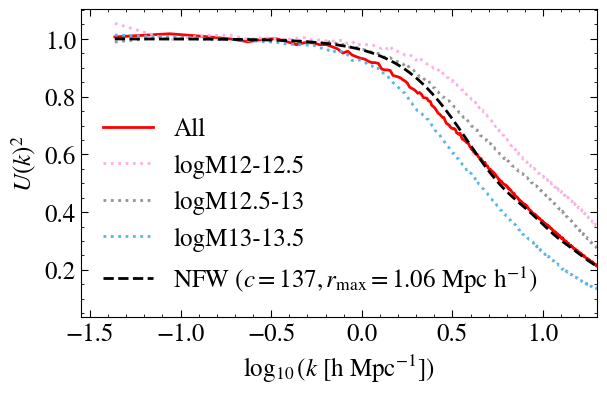

In [ ]:
plt.plot(np.log10(ks_tng), uk2_all, label="All", c="red")
#plt.plot(np.log10(ks_tng), uk2_11, label="TNG (logM11-11.1)")
plt.plot(np.log10(ks_tng), uk2_12, label="logM12-12.5", linestyle="dotted", c=palette_tab10[6])
plt.plot(np.log10(ks_tng), uk2_125, label="logM12.5-13", linestyle="dotted", c=palette_tab10[7])

plt.plot(np.log10(ks_tng), uk2_13, label="logM13-13.5", linestyle="dotted", c=palette_tab10[9])

#plt.plot(logks, ftc5, label="c=5")
#plt.plot(logks, ftc4, label="c=4")
#plt.plot(logks, ftc5, label=f"NFW, logM11 (c=5, Rmax=118)")
#plt.plot(logks, ft12, label=f"NFW, logM12 (c=4, Rmax=250)")
#plt.plot(logks, uk1, label=f"NFW, logM12 (c=5, Rmax=500)")
#plt.plot(logks, uk2, label=f"NFW, logM12 (c=5, Rmax=500)")

plt.plot(logks_tng, uk**2, label="NFW ($c=137, r_{\mathrm{max}}=$1.06 Mpc h$^{-1}$)", linestyle="dashed", c="k")

#plt.plot(logks, ft13, label=f"NFW, logM13 (c=3.5, Rmax=550)")
plt.ylabel("$U(k)^2$")
plt.xlabel(r"$\log_{10}(k\ [\mathrm{h\ Mpc^{-1}}])$")
plt.xlim(-1.55,1.3)
#plt.ylim(0,1)
plt.legend(loc="lower left")
#plt.savefig("../figures/u_k_squared_nfw.pdf", format="pdf", bbox_inches="tight")

In [34]:
logMmin = 13.0
logMmax = 13.1

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/sat_sum/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sat_sum = pickle.load(f)

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/sat/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sat = pickle.load(f)


In [39]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sat_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat10 = pickle.load(f)


with open(f"{odir}/snap40/mvir/ps-intensity-sat_sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat_sum10 = pickle.load(f)

In [36]:

uk2_13_sat = compute_uk2(Pk13_sat, Pk13_sat_sum)

In [40]:

uk2_sat = compute_uk2(Pk_sat10, Pk_sat_sum10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


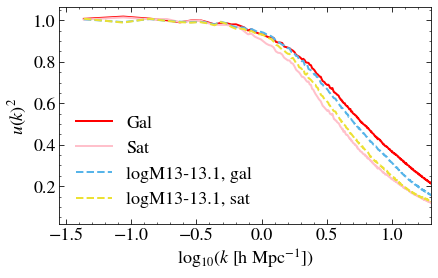

In [43]:
plt.plot(np.log10(ks_tng), uk2_all, label="Gal", c="red")
plt.plot(np.log10(ks_tng), uk2_sat, label="Sat", c="pink")
#plt.plot(np.log10(ks_tng), uk2_11, label="TNG (logM11-11.1)")

plt.plot(np.log10(ks_tng), uk2_13, label="logM13-13.1, gal", linestyle="dashed", c=palette_tab10[9])

plt.plot(np.log10(ks_tng), uk2_13_sat, label="logM13-13.1, sat", linestyle="dashed", c=palette_tab10[8])

#plt.plot(logks, ftc5, label="c=5")
#plt.plot(logks, ftc4, label="c=4")
#plt.plot(logks, ftc5, label=f"NFW, logM11 (c=5, Rmax=118)")
#plt.plot(logks, ft12, label=f"NFW, logM12 (c=4, Rmax=250)")
#plt.plot(logks, uk1, label=f"NFW, logM12 (c=5, Rmax=500)")
#plt.plot(logks, uk2, label=f"NFW, logM12 (c=5, Rmax=500)")

#plt.plot(logks, ft13, label=f"NFW, logM13 (c=3.5, Rmax=550)")
plt.ylabel("$u(k)^2$")
plt.xlabel(r"$\log_{10}(k\ [\mathrm{h\ Mpc^{-1}}])$")
plt.xlim(-1.55,1.3)
#plt.ylim(0,1)
plt.legend()
#plt.savefig("../figures/u_k_squared.pdf", format="pdf", bbox_inches="tight")